## 개요
따릉이 수요를 예측해본다.               
지역구는 은평구로 한정하며 군집화를 통하여 12개의 군집으로 나누었고 그 중에 3개를 뽑아서 진행한다

In [ ]:
# !pip install holidays
# !pip install koreanize_matplotlib

In [ ]:
import pandas as pd
import numpy as np
import warnings
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

================================================================== 


01. 파일 로드

In [ ]:
df2024 = pd.read_csv('../../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../../Data/Zero/2025_data.csv')

df = pd.concat([df2024,df2025],axis=0)
kr = holidays.KR()

,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
0,2024-01-01,0,출발시간,ST-481,ST-1692,1.0,3000,10340.0,-2.7,92,28.49784,0.0,0.0
1,2024-01-01,0,출발시간,ST-464,ST-456,1.0,2040,1900.0,-2.7,92,28.49784,0.0,0.0
2,2024-01-01,0,출발시간,ST-1486,ST-462,1.0,1140,1610.0,-2.7,92,28.49784,0.0,0.0
3,2024-01-01,0,출발시간,ST-2783,ST-462,1.0,4740,5725.0,-2.7,92,28.49784,0.0,0.0
4,2024-01-01,0,출발시간,ST-454,ST-1331,1.0,6900,11170.0,-2.7,92,28.49784,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
739708,2025-12-31,23,출발시간,ST-1034,ST-2207,1.0,120,448.0,-8.8,51,27.43588,0.0,0.0
739709,2025-12-31,23,출발시간,ST-2264,ST-479,1.0,180,334.0,-8.8,51,27.43588,0.0,0.0
739710,2025-12-31,23,출발시간,ST-479,ST-1025,1.0,420,1262.0,-8.8,51,27.43588,0.0,0.0
739711,2025-12-31,23,출발시간,ST-2470,ST-2425,1.0,1140,2659.0,-8.8,51,27.43588,0.0,0.0


==================================================================   


02. 지정된 스테이션으로 통합
- 3개 뽑은 스테이션을 정의함                
- 기준 날짜를 datetime으로 전환
- 전체 이용 시간과 전체 이용 거리가 최소한 5이상인 것들만 추출함
- 시작 대여소가 뽑은 스테이션에 해당하는 데이터만 추출함
- 시작 대여소, datetime, year를 기준으로 그룹화함. 전체 건수의 합, 온도, 습도, 불쾌지수, 강수량, 적설량의 평균으로 집어 넣음

In [ ]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-1481']
# target_station = ['ST-1035', 'ST-454', 'ST-471']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['year'] = df['기준_날짜'].dt.year
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)
df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_hourly = df.groupby(['시작_대여소_ID', 'datetime','year']).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
}).reset_index()


In [ ]:
df.to_csv("../../Data/st")

==================================================================        


03. 전처리 - 1
- datetime을 기준으로 hour, month, weekday, is_weekend, is_holiday 값 추출
- 1시간, 2시간, 3시간, 24시간 전 데이터를 가져옴
- 1시간 전을 기준으로 3시간의 평균 계산
- 시간을 sin과 cos으로 저장
- 달을 sin과 cos으로 저장

In [ ]:
# 1. 시간대와 요일 정보 다시 추출
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['month'] = df_hourly['datetime'].dt.month

df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)

df_hourly['rush_hour'] = (
    ((df_hourly['hour'] >= 7) & (df_hourly['hour'] <= 9)) |
    ((df_hourly['hour'] >= 17) & (df_hourly['hour'] <= 19))
).astype(int)

# 2. 대여소 ID를 숫자로 변환 (HGB가 대여소별 특징을 알게 함)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# df_hourly['station_idx'] = le.fit_transform(df_hourly['시작_대여소_ID'])
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])



df_hourly['lag_1h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(1)
df_hourly['lag_2h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(2)
df_hourly['lag_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(3)
df_hourly['lag_12h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(12)

df_hourly['lag_24h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(24)

df_hourly['rolling_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(lambda x: x.shift(1).rolling(3).mean())

df_hourly = df_hourly.dropna()

df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['month_sin'] = np.sin(2 * np.pi * df_hourly['month'] / 12)
df_hourly['month_cos'] = np.cos(2 * np.pi * df_hourly['month'] / 12)


In [ ]:
df_hourly

,시작_대여소_ID,datetime,year,전체_건수,온도,습도,불쾌지수,강수량,적설량,hour,...,lag_1h,lag_2h,lag_3h,lag_12h,lag_24h,rolling_3h,hour_sin,hour_cos,month_sin,month_cos
24,ST-1481,2024-02-08 17:00:00,2024,2.0,2.8,58.0,41.88176,0.0,0.0,17,...,2.0,2.0,2.0,2.0,2.0,2.0,-9.659258e-01,-0.258819,8.660254e-01,0.5
25,ST-1481,2024-02-12 14:00:00,2024,2.0,8.1,26.0,51.22794,0.0,0.0,14,...,2.0,2.0,2.0,2.0,2.0,2.0,-5.000000e-01,-0.866025,8.660254e-01,0.5
26,ST-1481,2024-02-13 12:00:00,2024,2.0,10.5,66.0,52.22770,0.0,0.0,12,...,2.0,2.0,2.0,2.0,2.0,2.0,1.224647e-16,-1.000000,8.660254e-01,0.5
27,ST-1481,2024-02-13 13:00:00,2024,2.0,12.1,59.0,54.73161,0.0,0.0,13,...,2.0,2.0,2.0,2.0,2.0,2.0,-2.588190e-01,-0.965926,8.660254e-01,0.5
28,ST-1481,2024-02-15 00:00:00,2024,2.0,8.7,100.0,47.66000,0.0,0.0,0,...,2.0,2.0,2.0,2.0,2.0,2.0,0.000000e+00,1.000000,8.660254e-01,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,ST-1481,2025-12-27 16:00:00,2025,2.0,-0.3,58.0,37.59074,0.0,0.0,16,...,2.0,2.0,2.0,2.0,2.0,2.0,-8.660254e-01,-0.500000,-2.449294e-16,1.0
1006,ST-1481,2025-12-28 15:00:00,2025,2.0,5.4,71.0,44.31666,0.7,0.0,15,...,2.0,2.0,2.0,2.0,2.0,2.0,-7.071068e-01,-0.707107,-2.449294e-16,1.0
1007,ST-1481,2025-12-29 08:00:00,2025,2.0,1.9,98.0,35.66838,0.0,0.0,8,...,2.0,2.0,2.0,2.0,2.0,2.0,8.660254e-01,-0.500000,-2.449294e-16,1.0
1008,ST-1481,2025-12-29 16:00:00,2025,2.0,7.2,62.0,47.68536,0.0,0.0,16,...,2.0,2.0,2.0,2.0,2.0,2.0,-8.660254e-01,-0.500000,-2.449294e-16,1.0


==================================================================        


03. 전처리 - 2
- 데이터에 없는 비어 있는 시간대를 만든다.
- 모든 대여소와 모든 시간을 카테시안 곱으로 결합해서 전체 조합을 만듬.
- 전체 건수가 널이면 0으로 채움
- 기상 변수들을 앞의 값으로 채워줌
- 타켓 스테이션들을 one hot encoding으로 넣어줌(근데 안 씀)
- 요일을 one hot encoding으로 넣어줌(근데 안 씀)

In [ ]:
import numpy as np

# 1. 은평구 주요 지하철역 위경도 데이터 (예시)
# 실제 예측 시에는 더 많은 역을 추가하거나 공공데이터를 활용할 수 있습니다.
subway_stations = {
    '연신내역': (37.6188, 126.9207),
    '구파발역': (37.6367, 126.9188),
    '불광역': (37.6105, 126.9298),
    '응암역': (37.5986, 126.9155),
    '디지털미디어시티역': (37.5767, 126.8990),
    '녹번역': (37.6009, 126.9357)
}

# 2. 하버사인 거리 계산 함수 정의
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # 지구 반지름 (km)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# 3. 분석 중인 스테이션의 위경도 (예시 좌표 - 실제 데이터에 맞게 수정 필요)
# 'ST-1483', 'ST-1481', 'ST-453' 의 실제 위경도를 입력하세요.
station_coords = {
    'ST-1483': (37.6185, 126.9210), # 연신내역 인근 가정
    'ST-1481': (37.6000, 126.9350), # 녹번역 인근 가정
    'ST-453': (37.5980, 126.9150)   # 응암역 인근 가정
}

# 4. 각 대여소별 가장 가까운 지하철역까지의 거리 계산
def get_min_dist_to_subway(station_id):
    if station_id not in station_coords:
        return 1.0 # 정보가 없으면 평균적인 거리 부여
    
    s_lat, s_lon = station_coords[station_id]
    distances = [haversine_distance(s_lat, s_lon, sub_lat, sub_lon) 
                 for sub_lat, sub_lon in subway_stations.values()]
    return min(distances)

# 5. 데이터프레임에 적용 (df_hourly 생성 시점에 적용)
# 기존 df_hourly에 '시작_대여소_ID'가 원본 형태로 남아있을 때 실행
df_hourly['dist_to_subway'] = df_hourly['시작_대여소_ID'].apply(get_min_dist_to_subway)

In [ ]:
# all_stations = df_hourly['시작_대여소_ID'].unique()
all_times = pd.date_range(start=df_hourly['datetime'].min(), 
                          end=df_hourly['datetime'].max(), 
                          freq='h')

multi_idx = pd.MultiIndex.from_product([target_station, all_times], 
                                       names=['시작_대여소_ID', 'datetime'])
df_full = pd.DataFrame(index=multi_idx).reset_index()

df_hourly = pd.merge(df_full, df_hourly, on=['시작_대여소_ID', 'datetime'], how='left')

df_hourly['전체_건수'] = df_hourly['전체_건수'].fillna(0) # 대여 없는 시간은 0건
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly['month'] = df_hourly['datetime'].dt.month
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] = \
    df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].ffill()
df_hourly['rolling_3h_std'] = (
    df_hourly.groupby('시작_대여소_ID')['전체_건수']
    .transform(lambda x: x.rolling(3).std())
    .fillna(0)
)
# 평일/주말과 시간을 결합한 교차 변수 생성
df_hourly['hour_working_day'] = df_hourly['hour'] * (1 - df_hourly['is_weekend'])
df_hourly['hour_weekend'] = df_hourly['hour'] * df_hourly['is_weekend']
df_hourly['is_rainy'] = (df_hourly['강수량'] > 0).astype(int)
df_hourly['rain_rush'] = df_hourly['is_rainy'] * df_hourly['hour_working_day']


df_hourly = pd.get_dummies(df_hourly, columns=['시작_대여소_ID'], prefix='st')
df_hourly = pd.get_dummies(df_hourly, columns=['weekday'])
# 2. 새로운 피처 리스트 생성 (기 station_idx 제외하고 새로 생긴 st_... 컬럼들 추가)
station_cols = [col for col in df_hourly.columns if col.startswith('st_')]
weekday_cols = [col for col in df_hourly.columns if col.startswith('weekday_')]
target = '전체_건수'
features = [
    # 'hour',
      # 'weekday', 
      # 'datetime',
    # 'is_weekend',
    #  'is_holiday',
    '온도', '습도',
      # '불쾌지수',
        '강수량', '적설량',
    # 'lag_1h', 
    # 'lag_2h',
    #   'rolling_3h',
    # 'lag_12h',
      # 'lag_24h',
    'hour_sin',
    'month_sin',
      'hour_cos',
      'month_cos',
      # 'rush_hour'
      'st_ST-1481',
       'weekday_0.0', 'weekday_1.0', 'weekday_2.0', 'weekday_3.0',
       'weekday_4.0', 'weekday_5.0', 'weekday_6.0'




]

In [ ]:
df_hourly.columns

Index(['datetime', 'year', '전체_건수', '온도', '습도', '불쾌지수', '강수량', '적설량', 'hour',
       'month', 'is_weekend', 'is_holiday', 'rush_hour', 'lag_1h', 'lag_2h',
       'lag_3h', 'lag_12h', 'lag_24h', 'rolling_3h', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'dist_to_subway', 'rolling_3h_std',
       'hour_working_day', 'hour_weekend', 'is_rainy', 'rain_rush',
       'st_ST-1481', 'weekday_0.0', 'weekday_1.0', 'weekday_2.0',
       'weekday_3.0', 'weekday_4.0', 'weekday_5.0', 'weekday_6.0'],
      dtype='str')

==================================================================        


04. 값
- 2024년은 train, 2025년은 test로 지정
- HistGradientBoostingRegressor 모델 사용해서 학습 


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor

train = df_hourly[df_hourly['year'] == 2024]
test  = df_hourly[df_hourly['year'] == 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

x_input, x_valid, y_input, y_valid = train_test_split(
    X_train, y_train, random_state=42, test_size=0.2, shuffle=False
)

# 기존 HGB
hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)
# lightgbm
lgbm_strong = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=10,
    min_child_samples=50,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=3.0,
    random_state=42,
    verbose=-1
)

# 추가: Ridge
ridge = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    # RidgeCV(alphas=np.logspace(-3, 3, 30))
    Ridge(alpha=1.0)
)

# =========================
# 공통 평가 함수
# =========================
def evaluate_model(model, model_name):
    print(f"\n{'=' * 20} {model_name} {'=' * 20}")

    scores = cross_validate(
        model,
        X_train,
        np.log1p(y_train),
        cv=5,
        n_jobs=1,
        return_train_score=True
    )

    print("CV train score(log) mean:", np.mean(scores['train_score']))
    print("CV valid score(log) mean:", np.mean(scores['test_score']))
    print("=" * 50)

    # input / valid 학습
    model.fit(x_input, np.log1p(y_input))

    print("Input score(log):", model.score(x_input, np.log1p(y_input)))
    print("Valid score(log):", model.score(x_valid, np.log1p(y_valid)))
    print("=" * 50)

    pred_input = np.expm1(model.predict(x_input))
    pred_valid = np.expm1(model.predict(x_valid))

    print("INPUT MAE :", mean_absolute_error(y_input, pred_input))
    print("INPUT RMSE:", np.sqrt(mean_squared_error(y_input, pred_input)))
    print("INPUT R2  :", r2_score(y_input, pred_input))

    print("-" * 50)

    print("VALID MAE :", mean_absolute_error(y_valid, pred_valid))
    print("VALID RMSE:", np.sqrt(mean_squared_error(y_valid, pred_valid)))
    print("VALID R2  :", r2_score(y_valid, pred_valid))

    print("=" * 50)

    # 최종 모델: 2024 전체 재학습
    model.fit(X_train, np.log1p(y_train))

    pred_train = np.expm1(model.predict(X_train))
    pred_test = np.expm1(model.predict(X_test))

    print("TRAIN MAE :", mean_absolute_error(y_train, pred_train))
    print("TRAIN RMSE:", np.sqrt(mean_squared_error(y_train, pred_train)))
    print("TRAIN R2  :", r2_score(y_train, pred_train))

    print("-" * 50)

    print("TEST MAE :", mean_absolute_error(y_test, pred_test))
    print("TEST RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))
    print("TEST R2  :", r2_score(y_test, pred_test))


# 실행
evaluate_model(hgb, "HistGradientBoosting")
evaluate_model(ridge, "Ridge")
evaluate_model(lgbm_strong, "LightGBM")


==================== HistGradientBoosting ====================
CV train score(log) mean: 0.9980115184958013
CV valid score(log) mean: 0.9607560642943074
Input score(log): 0.997583363685149
Valid score(log): 0.9858518503769966
INPUT MAE : 0.009587698072941093
INPUT RMSE: 0.06226698452267938
INPUT R2  : 0.9897046288745266
--------------------------------------------------
VALID MAE : 0.009577631806668773
VALID RMSE: 0.08705378688378625
VALID R2  : 0.9451645684928593
TRAIN MAE : 0.008283698040602533
TRAIN RMSE: 0.05847900276360109
TRAIN R2  : 0.9896512023882077
--------------------------------------------------
TEST MAE : 0.021391914818881825
TEST RMSE: 0.1561725880933312
TEST R2  : 0.8968023525490564

==================== Ridge ====================
CV train score(log) mean: 0.97135003798291
CV valid score(log) mean: 0.9716136996769997
Input score(log): 0.9689297600667854
Valid score(log): 0.9892044973677075
INPUT MAE : 0.03034682642550137
INPUT RMSE: 0.20787043022693966
INPUT R2  : 0.88

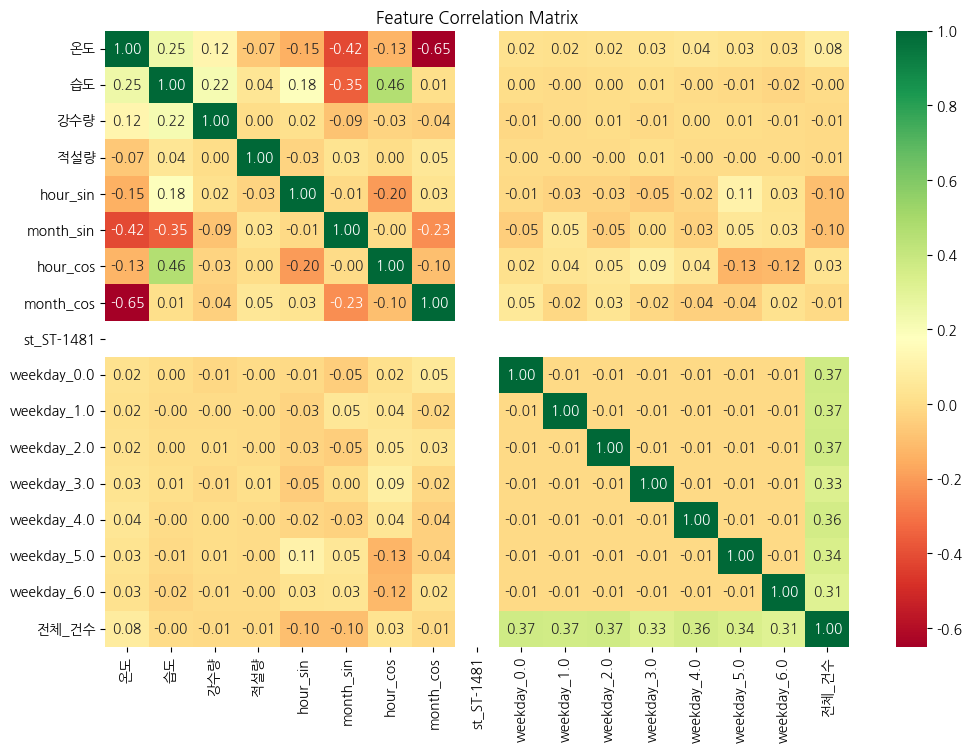

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 분석에 사용할 변수들만 추출
corr_df = df_hourly[features + [target]]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

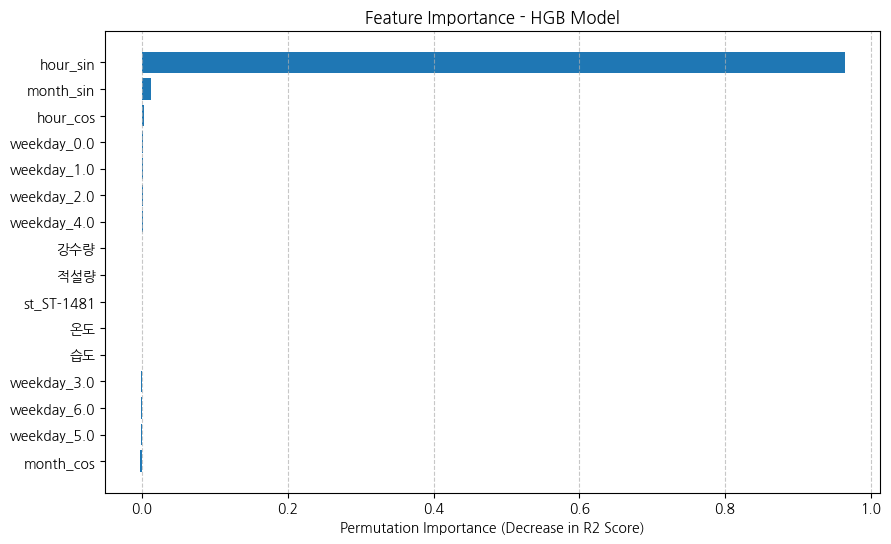

In [ ]:
from sklearn.inspection import permutation_importance

# 테스트 데이터셋을 기준으로 측정합니다.
result = permutation_importance(hgb, X_test, y_test, n_repeats=10, random_state=42)

# 시각화를 위해 정렬
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(np.array(features)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Decrease in R2 Score)")
plt.title("Feature Importance - HGB Model")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()